# Thread 4: Suppression of Dissent

### This thread looks at the different instances when the government unfairly used it's power to silence the population with conflicting opinion challenging it's authority.

## Analysis

# Importing Libraries

In [7]:
import sys
sys.path.append("..")
import utility as u
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
importlib.reload(u)

<module 'utility' from '/Users/bhavya/Documents/DS/The Committee Will Look Into It/04_Suppression_of_Dissent/../utility.py'>

# Loading dataset

In [8]:
df= u.load_data('data/df_cleaned.csv')

In [9]:
sec144 = df[df["event_type"] == "sec144"].copy()
shutdowns = df[df["event_type"] == "internet_shutdown"].copy()

## 1. Delhi data analysis

Chart saved- charts/chart1_delhi_sec144_districts_bar.png


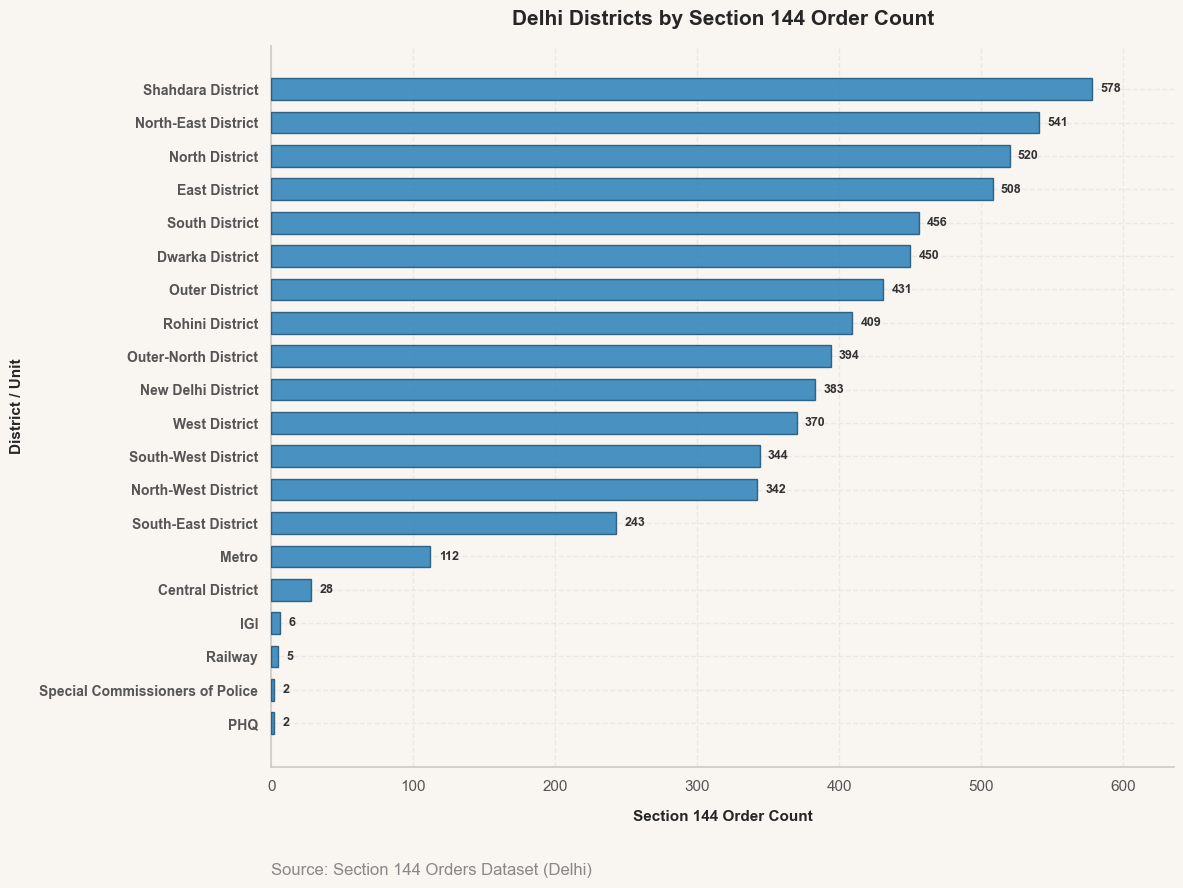

In [10]:
u.set_style()

df.columns = df.columns.str.strip()

# Ensure numeric values and sort ascending for horizontal bar chart readability
sec144["sec144_order_count"] = pd.to_numeric(
    sec144["sec144_order_count"], errors="coerce"
).fillna(0)

sec144_sorted = sec144.sort_values(by="sec144_order_count", ascending=True)



fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y_pos = range(len(sec144_sorted))
bars = ax.barh(
    list(y_pos),
    sec144_sorted["sec144_order_count"],
    color="#2980b9",
    alpha=0.85,
    height=0.65,
    edgecolor="#1a5276",
    zorder=3,
)


ax.set_yticks(list(y_pos))
ax.set_yticklabels(sec144_sorted["district"], fontsize=10, fontweight="bold")
ax.set_xlabel("Section 144 Order Count", fontsize=11, fontweight="bold")
ax.set_ylabel("District / Unit", fontsize=11, fontweight="bold")
ax.set_title(
    "Delhi Districts by Section 144 Order Count",
    fontsize=15,
    fontweight="bold",
    pad=15,
)


x_max = sec144_sorted["sec144_order_count"].max()
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{int(width)}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

ax.set_xlim(right=x_max * 1.1)


u.add_source(ax, "Section 144 Orders Dataset (Delhi)", fontsize= 12)

plt.tight_layout()
u.save_fig(fig, "charts", "chart1_delhi_sec144_districts_bar.png")
plt.show()

Chart saved- charts/chart2_shutdowns_by_state.png


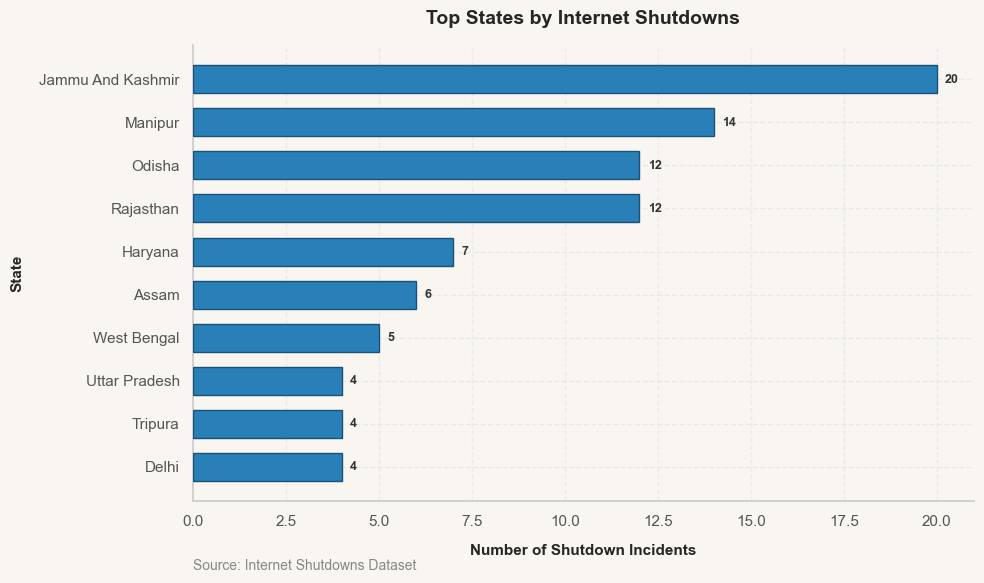

In [11]:
u.set_style()

df.columns = df.columns.str.strip()

shutdowns = df[df["event_type"] == "internet_shutdown"].copy()

state_col = [col for col in shutdowns.columns if "state" in col.lower()][0]
shutdowns["state_clean"] = shutdowns[state_col].astype(str).str.strip().str.title()

top_states = (
    shutdowns["state_clean"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)



fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    top_states.index,
    top_states.values,
    color="#2980b9",
    edgecolor="#1a5276",
    height=0.65,
    zorder=3,
)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{int(width):,}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

ax.set_title(
    "Top States by Internet Shutdowns",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Shutdown Incidents", fontsize=11, fontweight="bold")
ax.set_ylabel("State", fontsize=11, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

u.add_source(ax, "Internet Shutdowns Dataset", fontsize=10)

plt.tight_layout()
u.save_fig(fig, "charts", "chart2_shutdowns_by_state.png")
plt.show()

NameError: name 'breakdown_df' is not defined

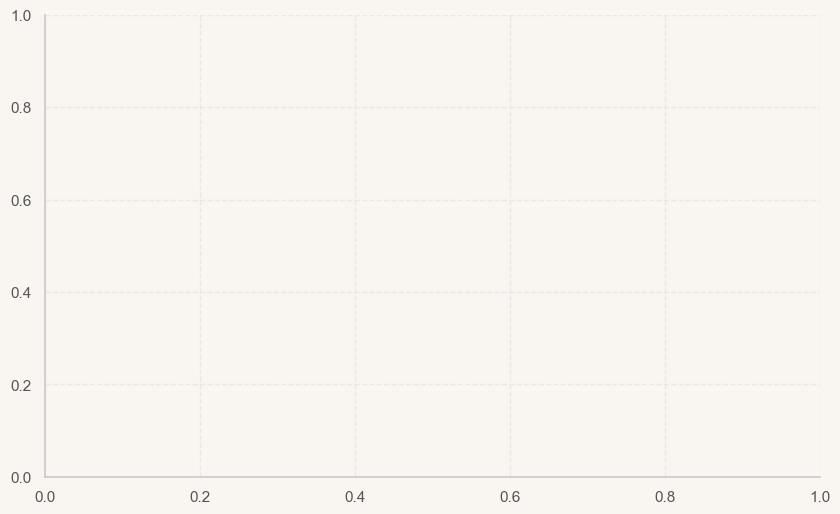

In [12]:
u.set_style()

shutdown_counts = shutdowns["nature"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

x = np.arange(len(breakdown_df.index))
width = 0.35

bars = ax.bar(
    shutdown_counts.index,
    shutdown_counts.values,
    color=["#2980b9", "#e74c3c"],
    edgecolor="#1a1a1a",
    alpha=0.9,
    zorder=3
)

ax.bar_label(bars, padding=3, fontsize=10, fontweight="bold")

ax.set_title("Preventive vs Reactive Internet Shutdowns", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Nature of Shutdown", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Incidents", fontsize=11, fontweight="bold")

u.add_source(ax, "Internet Shutdowns Dataset", fontsize=10)
plt.tight_layout()
u.save_fig(fig, "charts", "chart3_preventive_vs_reactive.png")
plt.show()

In [ ]:
shutdowns["date"] = pd.to_datetime(shutdowns["date"])
shutdowns["year"] = shutdowns["date"].dt.year
print(shutdowns["year"].unique())

[2026 2025 2024]


Chart saved- charts/chart4_manipur_deep_dive.png


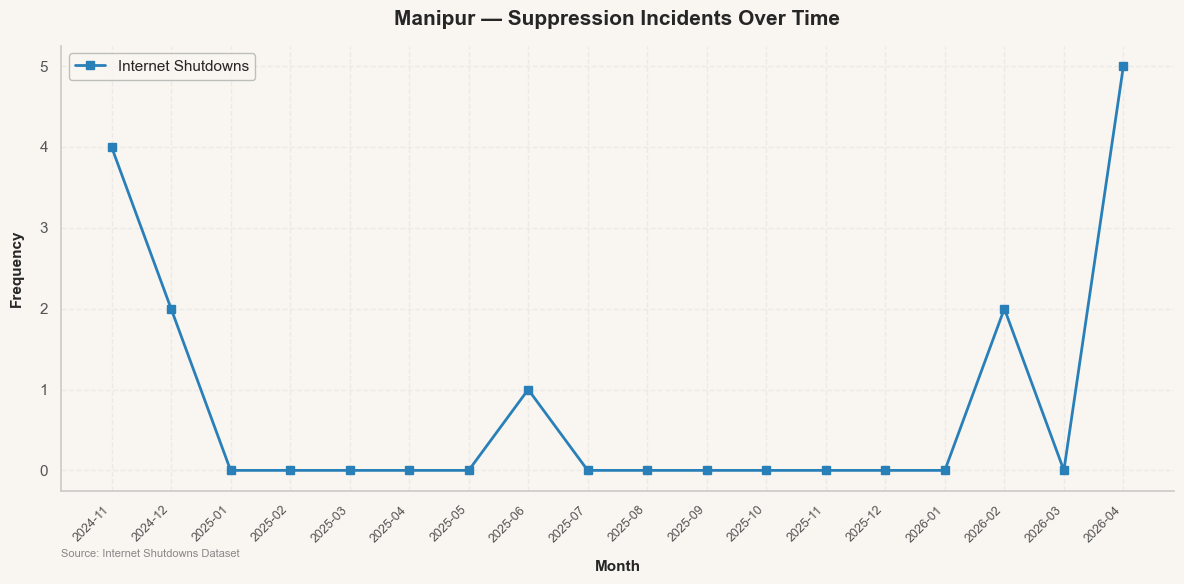

In [ ]:
u.set_style()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year

manipur = df[df["state"] == "Manipur"].copy()
manipur["time_period"] = manipur["date"].dt.to_period("M")

shutdown_m = manipur[manipur["event_type"] == "internet_shutdown"].groupby("time_period").size()

full_range = pd.period_range(
    start=manipur["time_period"].min(),
    end=manipur["time_period"].max(),
    freq="M"
)

timeline_df = pd.DataFrame({
    "Internet Shutdowns": shutdown_m
}, index=full_range).fillna(0)

timeline_df.index = timeline_df.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

ax.plot(timeline_df.index, timeline_df["Internet Shutdowns"],
        marker="s", linewidth=2, color="#2980b9", label="Internet Shutdowns", zorder=3)

ax.set_title("Manipur — Suppression Incidents Over Time",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=11, fontweight="bold")
ax.set_ylabel("Frequency", fontsize=11, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)
ax.legend(frameon=True, facecolor=u.BG_COLOR, edgecolor="#b0b0b0")
u.add_source(ax, "Internet Shutdowns Dataset")

plt.tight_layout()
u.save_fig(fig, "charts", "chart4_manipur_deep_dive.png")
plt.show()

Chart saved- charts/chart5_internet_shutdowns_yearwise.png


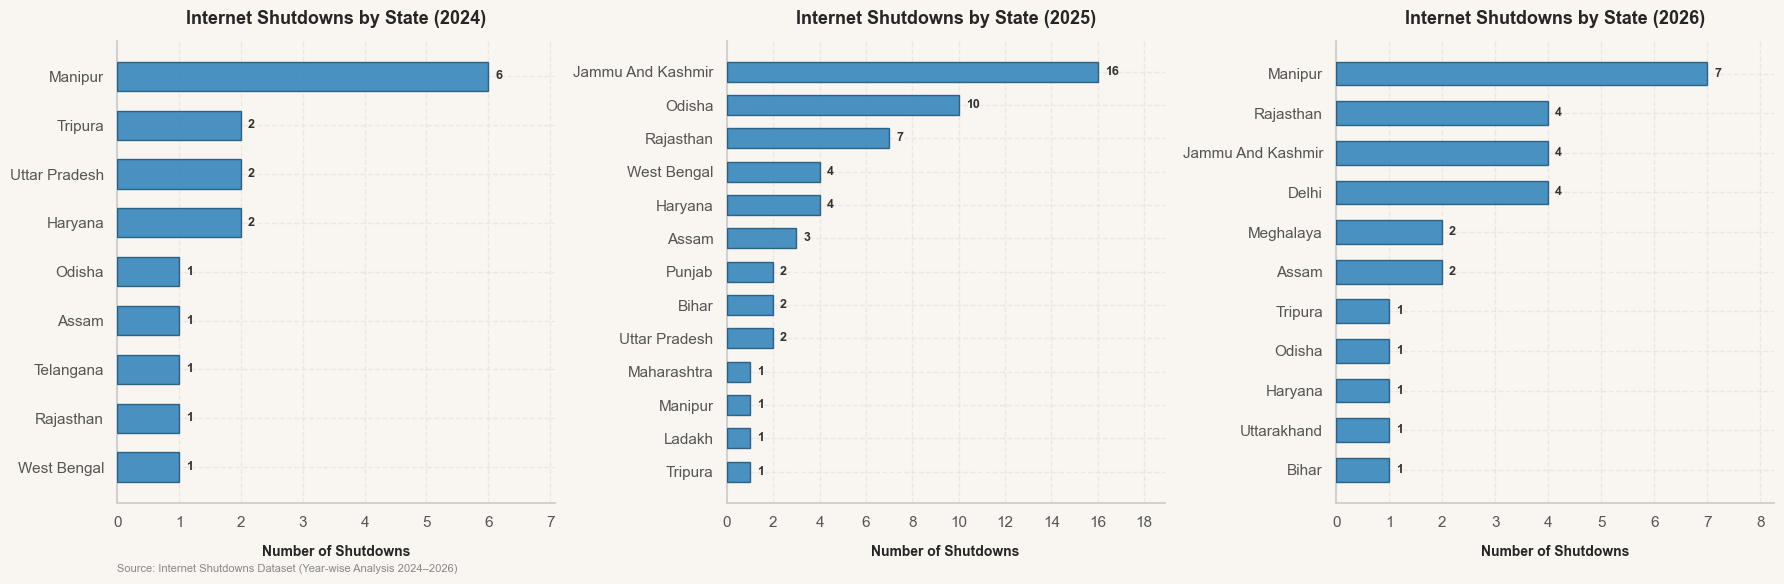

In [ ]:
u.set_style()

years = sorted(shutdowns["year"].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(u.BG_COLOR)

for idx, yr in enumerate(years):
    ax = axes[idx]
    ax.set_facecolor(u.BG_COLOR)

    state_counts = (
        shutdowns[shutdowns["year"] == yr]["state"]
        .value_counts()
        .reset_index()
    )
    state_counts.columns = ["state", "count"]
    state_counts = state_counts.sort_values("count", ascending=True)

    bars = ax.barh(
        state_counts["state"],
        state_counts["count"],
        color="#2980b9",
        edgecolor="#1a5276",
        height=0.6,
        alpha=0.85,
        zorder=3,
    )

    ax.set_title(
        f"Internet Shutdowns by State ({yr})",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Number of Shutdowns", fontsize=10, fontweight="bold")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    max_val = state_counts["count"].max()
    ax.set_xlim(0, max_val * 1.18)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="#333333",
        )

u.add_source(
    axes[0], "Internet Shutdowns Dataset (Year-wise Analysis 2024–2026)"
)

plt.tight_layout()
u.save_fig(fig, "charts", "chart5_internet_shutdowns_yearwise.png")
plt.show()

Chart saved- charts/chart6_shutdown_political_timeline.png


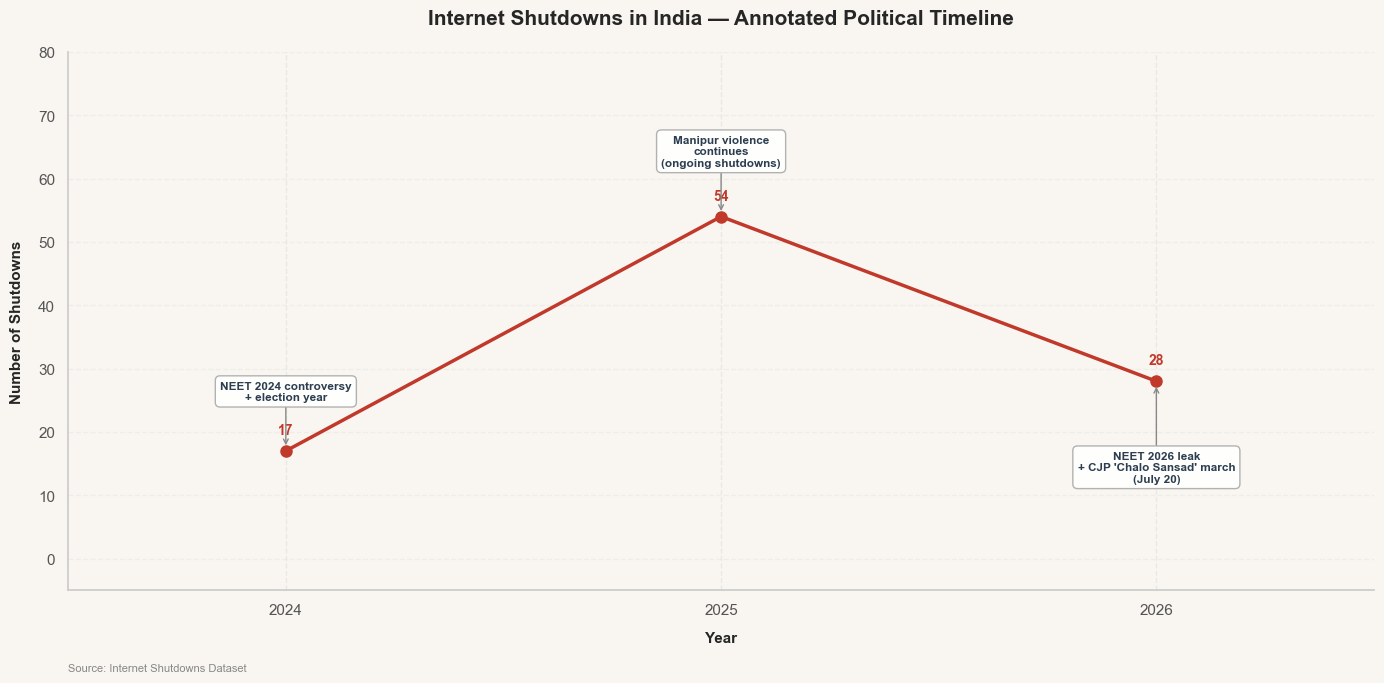

In [ ]:
u.set_style()

yearly_shutdowns = (
    shutdowns.groupby("year").size().reset_index(name="shutdown_count")
)

# Political events to annotate — (year, label, point_offset_y)
events = [
    (2024, "NEET 2024 controversy\n+ election year", 35),
    (2025, "Manipur violence\ncontinues\n(ongoing shutdowns)", 35),
    (2026, "NEET 2026 leak\n+ CJP 'Chalo Sansad' march\n(July 20)", -50),
]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)


ax.plot(
    yearly_shutdowns["year"],
    yearly_shutdowns["shutdown_count"],
    color="#c0392b",
    marker="o",
    linewidth=2.5,
    markersize=8,
    zorder=4,
)

for _, row in yearly_shutdowns.iterrows():
    # Keep label above the point except for 2026 where box is below
    y_pos_offset = 12 if row["year"] != 2026 else 12
    ax.annotate(
        f"{int(row['shutdown_count'])}",
        xy=(row["year"], row["shutdown_count"]),
        xytext=(0, y_pos_offset),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#c0392b",
        zorder=5,
    )

for yr, label, pt_offset in events:
    match = yearly_shutdowns[yearly_shutdowns["year"] == yr]
    if match.empty:
        continue
    y_val = match["shutdown_count"].values[0]

    ax.annotate(
        label,
        xy=(yr, y_val),
        xytext=(0, pt_offset),
        textcoords="offset points",
        fontsize=8.5,
        ha="center",
        va="bottom" if pt_offset > 0 else "top",
        color="#2c3e50",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#ffffff",
            edgecolor="#aaaaaa",
            alpha=0.9,
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="#888888",
            lw=1.0,
            shrinkA=0,
            shrinkB=4,
        ),
        zorder=5,
    )

ax.set_ylim(-5, 80)
ax.set_xlim(2023.5, 2026.5)

ax.set_title(
    "Internet Shutdowns in India — Annotated Political Timeline",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Year", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel(
    "Number of Shutdowns", fontsize=11, fontweight="bold", labelpad=10
)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

u.add_source(ax, "Internet Shutdowns Dataset")

plt.tight_layout()
u.save_fig(fig, "charts", "chart6_shutdown_political_timeline.png")
plt.show()